# 01 — EDA: Raw Transaction Data

UCI Online Retail II — a UK-based online retailer's transactional records (2009-12-01 → 2011-12-09, ~1M line items). One row per invoice line. No churn label; this notebook explores structure and quality only.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_SEED = 42
DATA_DIR = Path('..') / 'data' / 'raw'

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 1. Load Data

In [30]:
df = pd.read_csv(
    DATA_DIR / 'online_retail_II.csv',
    dtype={'Customer ID': 'Int64'},
    parse_dates=['InvoiceDate'],
    encoding='ISO-8859-1',
)

df = df.rename(columns={
    'Invoice': 'invoice',
    'StockCode': 'stock_code',
    'Description': 'description',
    'Quantity': 'quantity',
    'InvoiceDate': 'invoice_date',
    'Price': 'price',
    'Customer ID': 'customer_id',
    'Country': 'country',
})

print(df.shape)
df.head(10)


(1067371, 8)


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom


In [31]:
print(f'Rows                : {len(df):,}')
print(f'Unique invoices     : {df["invoice"].nunique():,}')
print(f'Unique stock codes  : {df["stock_code"].nunique():,}')
print(f'Unique customers    : {df["customer_id"].nunique():,} (excluding nulls)')
print(f'Unique countries    : {df["country"].nunique()}')
print(f'Invoice date range  : {df["invoice_date"].min()} → {df["invoice_date"].max()}')


Rows                : 1,067,371
Unique invoices     : 53,628
Unique stock codes  : 5,305
Unique customers    : 5,942 (excluding nulls)
Unique countries    : 43
Invoice date range  : 2009-12-01 07:45:00 → 2011-12-09 12:50:00


## 2. Schema & Data Types

In [32]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice       1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   price         1067371 non-null  float64       
 6   customer_id   824364 non-null   Int64         
 7   country       1067371 non-null  object        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 66.2+ MB


## 3. Missing Values

In [33]:
missing_pct = df.isnull().mean() * 100
missing_pct.round(3)


invoice         0.00
stock_code      0.00
description     0.41
quantity        0.00
invoice_date    0.00
price           0.00
customer_id    22.77
country         0.00
dtype: float64

## 4. Data Quality Checks

Things to verify on a raw transactional dump:
- Cancellations (invoices prefixed with `C`) and how they correlate with negative quantities.
- For returns (negative quantity), whether `price` is also signed negative or stays positive.
- Non-positive prices (data errors, adjustments).
- Exact duplicate rows.
- Rows with missing `customer_id` (cannot be attributed to a customer).


In [34]:
is_cancellation = df['invoice'].astype(str).str.startswith('C')
neg_qty          = (df['quantity'] < 0)
zero_qty         = (df['quantity'] == 0)
neg_price        = (df['price'] < 0)
zero_price       = (df['price'] == 0)
missing_customer = df['customer_id'].isna()
duplicates       = df.duplicated()

print(f'Cancellation invoices (C-prefix)   : {is_cancellation.sum():>8,} ({is_cancellation.mean()*100:.2f}%)')
print(f'Rows with quantity < 0             : {neg_qty.sum():>8,}')
print(f'Rows with quantity == 0            : {zero_qty.sum():>8,}')
print(f'Rows with price < 0                : {neg_price.sum():>8,}')
print(f'Rows with price == 0               : {zero_price.sum():>8,}')
print(f'Rows with missing customer_id      : {missing_customer.sum():>8,} ({missing_customer.mean()*100:.2f}%)')
print(f'Exact duplicate rows               : {duplicates.sum():>8,} ({duplicates.mean()*100:.2f}%)')

print()
print('Overlap: cancellation flag vs negative quantity')
print(pd.crosstab(is_cancellation, neg_qty, rownames=['is_cancellation'], colnames=['quantity<0']))

print()
print('For rows with negative quantity (returns), is price also negative?')
ret = df[neg_qty]
print(f'  Rows with quantity < 0      : {len(ret):,}')
print(f'    price > 0                 : {(ret["price"] > 0).sum():,}')
print(f'    price == 0                : {(ret["price"] == 0).sum():,}')
print(f'    price < 0                 : {(ret["price"] < 0).sum():,}')
print()
print('Price summary on negative-quantity rows:')
print(ret['price'].describe().round(2))


Cancellation invoices (C-prefix)   :   19,494 (1.83%)
Rows with quantity < 0             :   22,950
Rows with quantity == 0            :        0
Rows with price < 0                :        5
Rows with price == 0               :    6,202
Rows with missing customer_id      :  243,007 (22.77%)
Exact duplicate rows               :   34,335 (3.22%)

Overlap: cancellation flag vs negative quantity
quantity<0         False  True 
is_cancellation                
False            1044420   3457
True                   1  19493

For rows with negative quantity (returns), is price also negative?
  Rows with quantity < 0      : 22,950
    price > 0                 : 19,493
    price == 0                : 3,457
    price < 0                 : 0

Price summary on negative-quantity rows:
count   22,950.00
mean        38.10
std        549.83
min          0.00
25%          0.85
50%          2.25
75%          4.95
max     38,970.00
Name: price, dtype: float64


## 5. Cancellations

Cancellations are a sizeable share of the data and need to be treated explicitly downstream (e.g. excluded, or paired with the original purchase to compute net revenue). Here we just characterise them.


In [35]:
cancel_df = df[is_cancellation]
regular_df = df[~is_cancellation]

print(f'Cancellation rows         : {len(cancel_df):,}')
print(f'Regular rows              : {len(regular_df):,}')
print(f'Cancellation unique invoices : {cancel_df["invoice"].nunique():,}')
print(f'Regular unique invoices      : {regular_df["invoice"].nunique():,}')
print()
print('Quantity summary on cancellations:')
print(cancel_df['quantity'].describe().round(2))


Cancellation rows         : 19,494
Regular rows              : 1,047,877
Cancellation unique invoices : 8,292
Regular unique invoices      : 45,336

Quantity summary on cancellations:
count    19,494.00
mean        -25.19
std         805.10
min     -80,995.00
25%          -6.00
50%          -2.00
75%          -1.00
max           1.00
Name: quantity, dtype: float64


In [ ]:
N = 15

# Most-canceled items (by units canceled — flip sign so the number reads positive)
top_canceled = (cancel_df
    .groupby(['stock_code', 'description'])
    .agg(units_canceled=('quantity', lambda x: -x.sum()),
         n_cancel_invoices=('invoice', 'nunique'))
    .sort_values('units_canceled', ascending=False)
    .head(N)
    .reset_index())

# Most-popular items (by units sold, regular invoices only, positive quantity)
top_popular = (regular_df[regular_df['quantity'] > 0]
    .groupby(['stock_code', 'description'])
    .agg(units_sold=('quantity', 'sum'),
         n_invoices=('invoice', 'nunique'))
    .sort_values('units_sold', ascending=False)
    .head(N)
    .reset_index())

print(f'Top {N} most-canceled items (by units canceled):')
print(top_canceled.to_string(index=False))
print()
print(f'Top {N} most-popular items (by units sold, excluding cancellations):')
print(top_popular.to_string(index=False))

overlap = set(top_canceled['stock_code']) & set(top_popular['stock_code'])
print()
print(f'Overlap between top-{N} canceled and top-{N} popular: {len(overlap)} of {N} stock codes')
if overlap:
    overlap_view = (top_popular[top_popular['stock_code'].isin(overlap)]
        .merge(top_canceled[['stock_code', 'units_canceled', 'n_cancel_invoices']],
               on='stock_code', how='left'))
    overlap_view['cancel_to_sold_ratio_pct'] = (
        overlap_view['units_canceled'] / overlap_view['units_sold'] * 100
    ).round(2)
    print()
    print('Shared items (popular AND heavily canceled):')
    print(overlap_view.to_string(index=False))


## 6. Quantity & Price Distributions

Both columns are extremely long-tailed (a handful of bulk orders / high-value items dominate). Histograms below show actual values (no log transform) clipped at the 99th percentile so the shape is readable; raw percentile values are in the description table underneath.


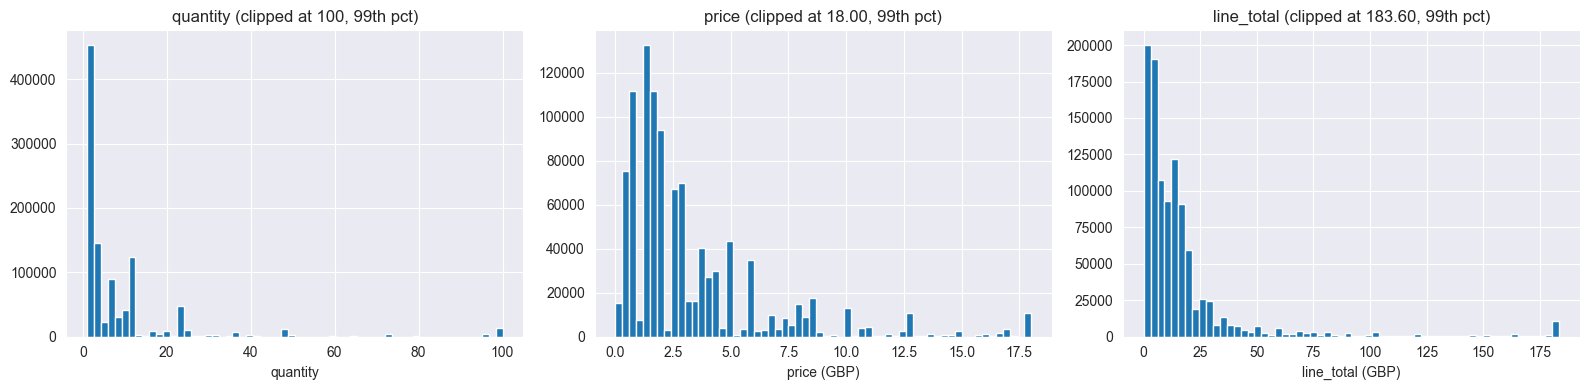

Summary (positive rows only):
          quantity        price   line_total
count 1,041,671.00 1,041,671.00 1,041,671.00
mean         10.96         4.08        20.13
std         126.51        51.45       203.12
min           1.00         0.00         0.00
50%           3.00         2.10         9.96
90%          24.00         7.95        33.00
99%         100.00        18.00       183.60
max      80,995.00    25,111.09   168,469.60


In [36]:
clean = df[(df['quantity'] > 0) & (df['price'] > 0)].copy()
clean['line_total'] = clean['quantity'] * clean['price']

q_clip = clean['quantity'].quantile(0.99)
p_clip = clean['price'].quantile(0.99)
t_clip = clean['line_total'].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(clean['quantity'].clip(upper=q_clip), bins=60)
axes[0].set_title(f'quantity (clipped at {q_clip:,.0f}, 99th pct)')
axes[0].set_xlabel('quantity')

axes[1].hist(clean['price'].clip(upper=p_clip), bins=60)
axes[1].set_title(f'price (clipped at {p_clip:,.2f}, 99th pct)')
axes[1].set_xlabel('price (GBP)')

axes[2].hist(clean['line_total'].clip(upper=t_clip), bins=60)
axes[2].set_title(f'line_total (clipped at {t_clip:,.2f}, 99th pct)')
axes[2].set_xlabel('line_total (GBP)')

for ax in axes:
    ax.ticklabel_format(style='plain', axis='both', useOffset=False)
    ax.yaxis.get_major_formatter().set_scientific(False)

plt.tight_layout()
plt.show()

print('Summary (positive rows only):')
print(clean[['quantity', 'price', 'line_total']].describe(percentiles=[0.5, 0.9, 0.99]).round(2))


## 7. Country Breakdown

In [ ]:
country_rows      = df['country'].value_counts()
country_customers = df.groupby('country')['customer_id'].nunique()
country_revenue   = (clean.groupby('country')['line_total'].sum().sort_values(ascending=False))

top = pd.DataFrame({
    'rows': country_rows,
    'rows_pct': (country_rows / country_rows.sum() * 100).round(2),
    'unique_customers': country_customers,
    'revenue_gbp': country_revenue.round(0),
}).fillna(0).sort_values('rows', ascending=False).head(15)
top


## 8. Top Products

In [38]:
top_products = (
    clean.groupby(['stock_code', 'description'])
    .agg(units_sold=('quantity', 'sum'),
         n_customers=('customer_id', 'nunique'),
         n_invoices=('invoice', 'nunique'),
         revenue=('line_total', 'sum'))
    .sort_values('units_sold', ascending=False)
    .head(15)
    .reset_index()
)
print('Top 15 stock codes by units sold (with unique customer counts):')
top_products


Top 15 stock codes by units sold (with unique customer counts):


,stock_code,description,units_sold,n_customers,n_invoices,revenue
0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,110138,482,1019,"25,259.90"
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,96086,1490,5356,"262,931.16"
2,84879,ASSORTED COLOUR BIRD ORNAMENT,81809,1010,2807,"132,187.92"
3,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,1,1,"168,469.60"
4,85099B,JUMBO BAG RED RETROSPOT,78860,860,3245,"148,823.92"
5,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,138,247,"81,700.92"
6,17003,BROCADE RING PURSE,71430,215,456,"14,959.19"
7,21977,PACK OF 60 PINK PAISLEY CAKE CASES,56794,767,1993,"28,490.98"
8,84991,60 TEATIME FAIRY CAKE CASES,54716,822,2127,"27,404.22"
9,22197,SMALL POPCORN HOLDER,49948,426,1407,"44,090.13"


## 9. Invoice-Level Aggregations

Each invoice contains multiple lines. Aggregate to one row per invoice and look at basket size and value. **All invoices are included** — cancellations and returns too — so a popular item that's constantly being returned still shows up here.


In [39]:
df['line_total'] = df['quantity'] * df['price']

invoice_agg = df.groupby('invoice').agg(
    n_lines=('stock_code', 'size'),
    n_unique_products=('stock_code', 'nunique'),
    total_quantity=('quantity', 'sum'),
    total_value=('line_total', 'sum'),
    invoice_date=('invoice_date', 'first'),
    customer_id=('customer_id', 'first'),
    country=('country', 'first'),
)
invoice_agg['is_cancellation'] = invoice_agg.index.astype(str).str.startswith('C')

print(f'Invoices : {len(invoice_agg):,}')
print(f'  Cancellation invoices : {invoice_agg["is_cancellation"].sum():,}')
print(f'  Regular invoices      : {(~invoice_agg["is_cancellation"]).sum():,}')
print()
print('Per-invoice summary (all invoices, includes returns):')
print(invoice_agg[['n_lines', 'n_unique_products', 'total_quantity', 'total_value']]
      .describe(percentiles=[0.5, 0.9, 0.99]).round(2))


Invoices : 53,628
  Cancellation invoices : 8,292
  Regular invoices      : 45,336

Per-invoice summary (all invoices, includes returns):
        n_lines  n_unique_products  total_quantity  total_value
count 53,628.00          53,628.00       53,628.00    53,628.00
mean      19.90              19.05          197.82       359.65
std       41.25              37.84        1,234.72     1,654.83
min        1.00               1.00      -87,167.00  -168,469.60
50%        9.00               9.00           93.00       196.34
90%       45.00              43.00          448.00       776.74
99%      177.00             172.00        1,992.00     3,840.18
max    1,350.00           1,110.00       87,167.00   168,469.60


## 10. Temporal Patterns

In [ ]:
df['line_total'] = df['quantity'] * df['price']

monthly = (df.assign(month=df['invoice_date'].dt.to_period('M'))
             .groupby('month')
             .agg(transactions=('invoice', 'nunique'),
                  revenue=('line_total', 'sum')))
monthly.index = monthly.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(monthly.index, monthly['transactions'], marker='o')
axes[0].set_title('Unique invoices per month (includes cancellations)')
axes[0].set_ylabel('Invoices')

axes[1].plot(monthly.index, monthly['revenue'], marker='o', color='tab:green')
axes[1].set_title('Net revenue per month (GBP, includes returns/cancellations)')
axes[1].set_ylabel('Revenue (GBP)')

for ax in axes:
    ax.ticklabel_format(style='plain', axis='y', useOffset=False)
    ax.yaxis.get_major_formatter().set_scientific(False)

plt.tight_layout()
plt.show()

monthly.round(0)


## 11. Customer-Level Transaction Counts & Retention

For each attributed customer (excluding rows with missing `customer_id`), what is the percentage who reach an Nth purchase (N = 1..30), and what is the average/median gap in days between the (N-1)th and Nth purchase? A "purchase" here is a **unique invoice** ordered by date (cancellation invoices still count as transactions).


In [40]:
df['line_total'] = df['quantity'] * df['price']
attributed = df.dropna(subset=['customer_id']).copy()

per_customer = attributed.groupby('customer_id').agg(
    n_invoices=('invoice', 'nunique'),
    n_lines=('stock_code', 'size'),
    total_spend=('line_total', 'sum'),
    first_purchase=('invoice_date', 'min'),
    last_purchase=('invoice_date', 'max'),
)
per_customer['active_days'] = (per_customer['last_purchase'] - per_customer['first_purchase']).dt.days

total_customers = len(per_customer)
print(f'Attributed customers : {total_customers:,}')
print()
print('Per-customer summary:')
print(per_customer[['n_invoices', 'n_lines', 'total_spend', 'active_days']]
      .describe(percentiles=[0.5, 0.9, 0.99]).round(2))

invoice_seq = (attributed
               .groupby(['customer_id', 'invoice'])['invoice_date']
               .min()
               .reset_index()
               .sort_values(['customer_id', 'invoice_date']))
invoice_seq['purchase_rank'] = invoice_seq.groupby('customer_id').cumcount() + 1
invoice_seq['gap_days'] = (invoice_seq
                           .groupby('customer_id')['invoice_date']
                           .diff()
                           .dt.total_seconds() / 86400)

max_n = 30
rows = []
for n in range(1, max_n + 1):
    reached = (per_customer['n_invoices'] >= n).sum()
    pct = reached / total_customers * 100
    if n >= 2:
        gap_rows = invoice_seq.loc[invoice_seq['purchase_rank'] == n, 'gap_days']
        mean_gap = round(gap_rows.mean(), 2) if len(gap_rows) else None
        median_gap = round(gap_rows.median(), 2) if len(gap_rows) else None
        transition = f'{n-1} -> {n}'
    else:
        mean_gap = None
        median_gap = None
        transition = '—'
    rows.append({
        'nth_purchase': n,
        'transition': transition,
        'customers_reaching': reached,
        'pct_of_total': round(pct, 2),
        'mean_days': mean_gap,
        'median_days': median_gap,
    })

retention = pd.DataFrame(rows)
print()
print('Retention curve & inter-purchase gaps (Nth purchase, N = 1..30):')
retention


Attributed customers : 5,942

Per-customer summary:
       n_invoices   n_lines  total_spend  active_days
count    5,942.00  5,942.00     5,942.00     5,942.00
mean         7.55    138.74     2,801.80       275.40
std         15.97    359.69    13,973.92       259.69
min          1.00      1.00   -25,111.09         0.00
50%          4.00     53.00       843.97       225.00
90%         17.00    322.90     5,257.36       672.00
99%         56.59  1,130.36    26,484.14       733.00
max        510.00 13,097.00   598,215.22       738.00

Retention curve & inter-purchase gaps (Nth purchase, N = 1..30):


,nth_purchase,transition,customers_reaching,pct_of_total,mean_days,median_days
0,1,—,5942,100.00,NaN,NaN
1,2,1 -> 2,4481,75.41,79.12,36.11
2,3,2 -> 3,3606,60.69,71.92,34.89
3,4,3 -> 4,2984,50.22,61.51,28.86
4,5,4 -> 5,2502,42.11,59.25,29.06
5,6,5 -> 6,2112,35.54,47.55,24.14
6,7,6 -> 7,1831,30.81,48.90,25.98
7,8,7 -> 8,1577,26.54,44.62,21.01
8,9,8 -> 9,1400,23.56,40.57,20.99
9,10,9 -> 10,1242,20.90,38.16,20.97


In [44]:
# Churn definition: a customer is "churn" if they do NOT make a 2nd purchase
# within N days of their 1st purchase. Customers whose 1st purchase is within
# the last N days of the dataset are excluded (right-censored — they have not
# had a full N-day window in which a 2nd purchase could occur).
dataset_end = df['invoice_date'].max()

first_purchase  = invoice_seq.loc[invoice_seq['purchase_rank'] == 1].set_index('customer_id')['invoice_date']
second_purchase = invoice_seq.loc[invoice_seq['purchase_rank'] == 2].set_index('customer_id')['invoice_date']

customer_purchases = pd.DataFrame({'first': first_purchase, 'second': second_purchase})
customer_purchases['days_to_second'] = (
    (customer_purchases['second'] - customer_purchases['first']).dt.total_seconds() / 86400
)

rows = []
for thresh in [30, 60, 90]:
    cutoff = dataset_end - pd.Timedelta(days=thresh)
    eligible = customer_purchases[customer_purchases['first'] <= cutoff]
    excluded = len(customer_purchases) - len(eligible)

    has_second_in_window = (eligible['days_to_second'] <= thresh).fillna(False)
    churned = (~has_second_in_window).sum()
    non_churned = has_second_in_window.sum()
    pct_churn = churned / len(eligible) * 100

    rows.append({
        'threshold_days': thresh,
        'eligible_customers': len(eligible),
        'excluded_right_censored': excluded,
        'churned': churned,
        'non_churned': non_churned,
        'pct_churned': round(pct_churn, 2),
        'pct_non_churned': round(100 - pct_churn, 2),
    })

churn_by_threshold = pd.DataFrame(rows)
print(f'Dataset end                : {dataset_end}')
print(f'Total attributed customers : {total_customers:,}')
print()
print('Churn % by 1st → 2nd-purchase window (churn = no 2nd purchase within N days of 1st):')
churn_by_threshold


Dataset end                : 2011-12-09 12:50:00
Total attributed customers : 5,942

Churn % by 1st → 2nd-purchase window (churn = no 2nd purchase within N days of 1st):


,threshold_days,eligible_customers,excluded_right_censored,churned,non_churned,pct_churned,pct_non_churned
0,30,5780,162,3775,2005,65.31,34.69
1,60,5581,361,2953,2628,52.91,47.09
2,90,5346,596,2433,2913,45.51,54.49


## 12. Inter-Purchase Gaps

For each customer with ≥ 2 invoices, days between consecutive invoices. Complementary view to the per-transition table in section 11 — shows the overall shape of the gap distribution.


Customers with ≥ 2 invoices : 4,481
Inter-invoice gap observations: 38,934

count   38,934.00
mean        42.09
std         69.96
min          0.00
50%         15.28
75%         48.04
90%        114.57
95%        180.97
99%        356.04
max        701.13
Name: gap_days, dtype: float64


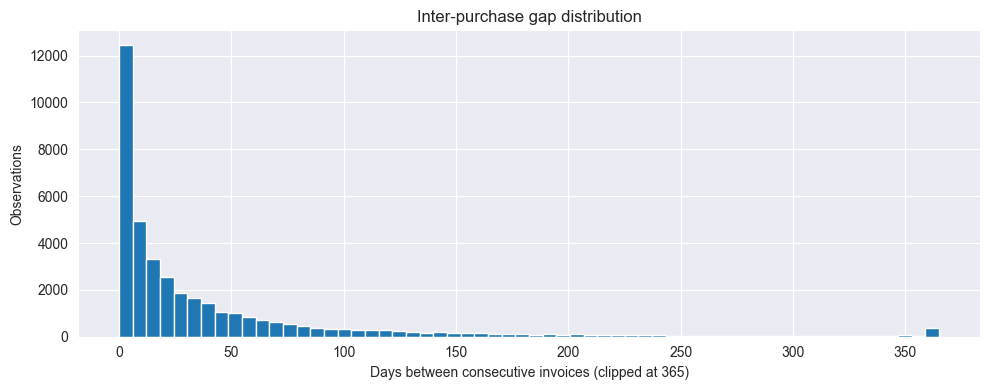

In [43]:
invoice_dates = (attributed
                 .groupby(['customer_id', 'invoice'])['invoice_date']
                 .min()
                 .reset_index()
                 .sort_values(['customer_id', 'invoice_date']))

invoice_dates['gap_days'] = (invoice_dates
                             .groupby('customer_id')['invoice_date']
                             .diff()
                             .dt.total_seconds() / 86400)

gaps = invoice_dates['gap_days'].dropna()
print(f'Customers with ≥ 2 invoices : {(per_customer["n_invoices"] >= 2).sum():,}')
print(f'Inter-invoice gap observations: {len(gaps):,}')
print()
print(gaps.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).round(2))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(gaps.clip(upper=365), bins=60)
ax.set_xlabel('Days between consecutive invoices (clipped at 365)')
ax.set_ylabel('Observations')
ax.set_title('Inter-purchase gap distribution')
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.get_major_formatter().set_scientific(False)
plt.tight_layout()
plt.show()


In [45]:
import os
print(f"CPU cores: {os.cpu_count()}")

CPU cores: 10
